# Neural Network

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
df = pd.read_csv('patient2025.csv')

# ลบ column HN ออกเพราะเป็น ID ไม่ส่งผลต่อการทำนาย
df = df.drop(columns=['HN'])

# ตรวจสอบค่าว่าง
print(df.isnull().sum())

FBS                           0
BMI                          60
Diabetes                      0
Chorestorol                   0
age                           0
hypertension                  0
vegetarian (1= yes, 0=no)     0
Marriage Status               0
Exercise (min/week)          26
Living Area                   0
stroke                        0
dtype: int64


## 1. Preprocessing

In [3]:
# 1. จัดการค่าว่าง (Imputation)
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['Exercise (min/week)'] = df['Exercise (min/week)'].fillna(df['Exercise (min/week)'].median())

# 2. แปลงค่าหมวดหมู่ (Encoding)
# ปรับ Diabetes ให้เป็นมาตรฐานเดียวกัน (ตัวเล็กทั้งหมด)
df['Diabetes'] = df['Diabetes'].str.lower()

# ใช้ LabelEncoder สำหรับคอลัมน์ที่มี 2 ค่า และ One-Hot สำหรับที่มีหลายค่า
le = LabelEncoder()
df['Diabetes'] = le.fit_transform(df['Diabetes']) # yes=1, no=0
df['Marriage Status'] = le.fit_transform(df['Marriage Status'])
df['Living Area'] = le.fit_transform(df['Living Area'])

# สำหรับ Chorestorol ที่มีช่วงและ 'Unknown' แนะนำให้ใช้ One-Hot Encoding
df = pd.get_dummies(df, columns=['Chorestorol'])

# 3. แยก Features (X) และ Target (y)
X = df.drop(columns=['stroke'])
y = df['stroke']

# 4. แบ่งข้อมูลสำหรับ Train และ Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. การปรับสเกลข้อมูล (Scaling) - สำคัญมากสำหรับ Neural Network
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Model Training

In [4]:
# นิยามโครงสร้าง Model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), # Hidden Layer 1
    Dropout(0.2), # ป้องกัน Overfitting
    Dense(16, activation='relu'), # Hidden Layer 2
    Dense(1, activation='sigmoid') # Output Layer สำหรับ Binary Classification
])

# Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# เริ่ม Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


C:\Users\khaop\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7219 - loss: 0.6021 - val_accuracy: 0.7375 - val_loss: 0.5448
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7406 - loss: 0.5488 - val_accuracy: 0.7312 - val_loss: 0.4995
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7547 - loss: 0.5172 - val_accuracy: 0.7375 - val_loss: 0.4708
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.4942 - val_accuracy: 0.7437 - val_loss: 0.4533
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7594 - loss: 0.4827 - val_accuracy: 0.7375 - val_loss: 0.4392
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7672 - loss: 0.4665 - val_accuracy: 0.7437 - val_loss: 0.4287
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7563 - loss: 0.4651 - val_accuracy: 0.7437 - val_loss: 0.4186
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7672 - loss: 0.4485 - val_accuracy: 0.7750 - val_loss: 0.4083
Ep

## 3. Test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7850 - loss: 0.4453  
Test Accuracy: 78.50%


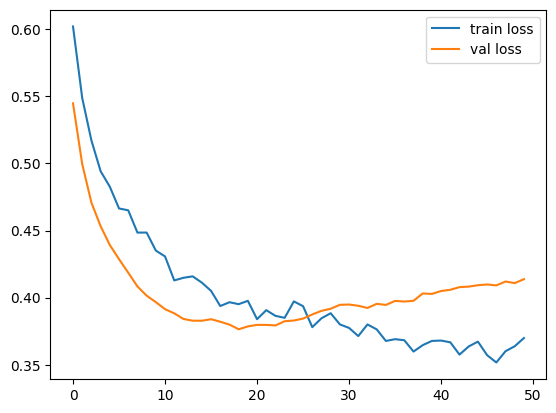

In [5]:
# ทดสอบกับข้อมูล Test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# พล็อตกราฟดู Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

## 4. Fine-Tunning

In [6]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping

optimizer = SGD(
    learning_rate=0.01,
    momentum=0.9
)

In [7]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),              # เพิ่ม Dropout
    Dense(16, activation='relu'),  # ลด capacity
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [8]:
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [10]:
# แก้ class imbalance
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.6722689075630253), 1: np.float64(1.951219512195122)}


In [11]:
# train
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4875 - loss: 0.7369 - val_accuracy: 0.6687 - val_loss: 0.6023
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6438 - loss: 0.6056 - val_accuracy: 0.7188 - val_loss: 0.5463
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6531 - loss: 0.6001 - val_accuracy: 0.7500 - val_loss: 0.5152
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7109 - loss: 0.5489 - val_accuracy: 0.7500 - val_loss: 0.4786
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7031 - loss: 0.5605 - val_accuracy: 0.7563 - val_loss: 0.4775
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7328 - loss: 0.5307 - val_accuracy: 0.7563 - val_loss: 0.4673
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7422 - loss: 0.5260 - val_accuracy: 0.7625 - val_loss: 0.4615
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7094 - loss: 0.5673 - val_accuracy: 0.7625 - 

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.6).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
[[118  38]
 [ 12  32]]
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       156
           1       0.46      0.73      0.56        44

    accuracy                           0.75       200
   macro avg       0.68      0.74      0.69       200
weighted avg       0.81      0.75      0.77       200



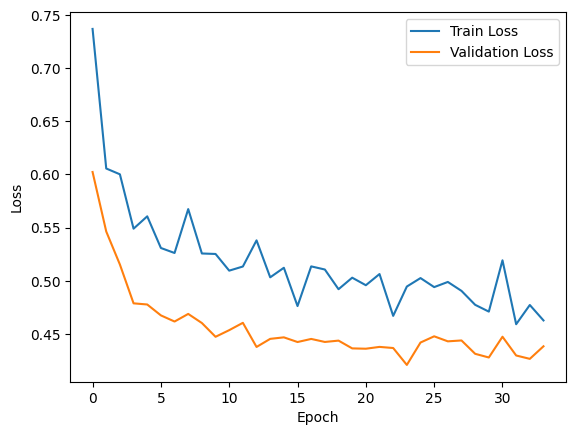

In [13]:
# กราฟ Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 5. Visualization

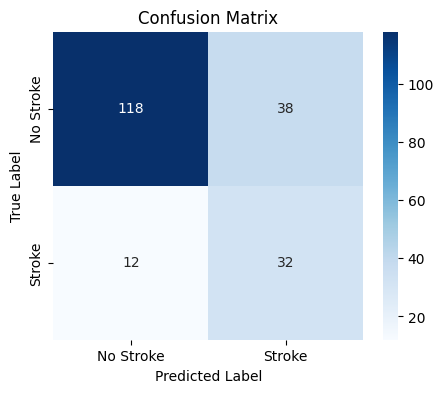

In [14]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

- โมเดลนี้เป็น Feedforward Neural Network สำหรับ Binary Classification
ใช้ Backpropagation และ Mini-batch Gradient Descent
เลือก SGD พร้อม Momentum เพื่อแก้ Local Minimum
ใช้ Dropout เพื่อป้องกัน Overfitting
Scaling ข้อมูลก่อนเรียนรู้
ใช้ Sigmoid + Binary Crossentropy สำหรับ Stroke Prediction

# Support Vector Machine

In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. โหลดข้อมูล
df = pd.read_csv('patient2025.csv')
print(df)


         HN     FBS   BMI Diabetes Chorestorol    age  hypertension  \
0     11223  228.69  34.0      yes     201-220  71.00             1   
1      8887  202.21   NaN       No     180-200  52.00             1   
2      5666  105.92  30.5      yes     180-200  78.00             1   
3    460182  171.23  35.0       No     221-260  54.00             1   
4    166665  174.12  28.0       No     180-200  79.00             1   
..      ...     ...   ...      ...         ...    ...           ...   
995   60211   90.51  18.9      yes     Unknown   1.40             0   
996   53279  118.87  16.3      yes     Unknown   0.24             0   
997   61715   56.42  31.8      yes     180-200  55.00             0   
998   37830   73.67  21.0       No     Unknown  29.00             0   
999    2454   89.11  20.1      yes     Unknown   4.00             0   

     vegetarian (1= yes, 0=no) Marriage Status  Exercise (min/week)  \
0                            1             Yes                  0.0   
1    

## 1. Preprocessing

In [16]:
# 2. Preprocessing
# ลบ ID ที่ไม่จำเป็น
df = df.drop(columns=['HN'])

# เติมค่าว่างด้วยค่ากลาง (Median)
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['Exercise (min/week)'] = df['Exercise (min/week)'].fillna(df['Exercise (min/week)'].median())

# ปรับค่า Diabetes ให้เป็นตัวเล็กทั้งหมดก่อนแปลง
df['Diabetes'] = df['Diabetes'].str.lower()

# แปลง Categorical เป็นตัวเลข
le = LabelEncoder()
df['Diabetes'] = le.fit_transform(df['Diabetes'])
df['Marriage Status'] = le.fit_transform(df['Marriage Status'])
df['Living Area'] = le.fit_transform(df['Living Area'])

# ใช้ One-Hot สำหรับ Chorestorol เพราะมีหลายระดับ
df = pd.get_dummies(df, columns=['Chorestorol'])

# 3. แยก Features และ Target
X = df.drop(columns=['stroke'])
y = df['stroke']

# 4. แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling (สำคัญที่สุดสำหรับ SVM เพื่อให้ระยะห่างแต่ละ Feature สมดุลกัน)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 2. Model Training

In [17]:
# สร้างโมเดล SVM โดยใช้ Kernel RBF (เป็นค่าเริ่มต้นที่นิยมที่สุด)
# C คือค่าที่คอยควบคุมความกว้างของ Margin
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# ฝึกสอนโมเดล
svm_model.fit(X_train, y_train)

SVC(random_state=42)

## 3. Test

Accuracy Score: 81.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       150
           1       0.70      0.42      0.53        50

    accuracy                           0.81       200
   macro avg       0.76      0.68      0.70       200
weighted avg       0.80      0.81      0.79       200



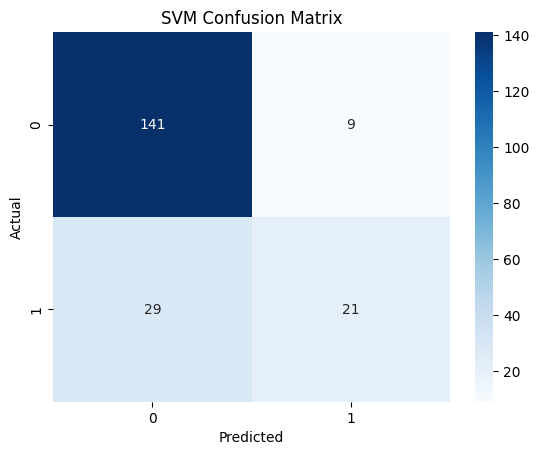

In [18]:
# ทำนายผล
y_pred = svm_model.predict(X_test)

# แสดงผลการทดสอบ
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# แสดง Confusion Matrix เพื่อดูการทายผิดในแต่ละคลาส
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

## 4. Fine-Tunning

In [19]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',   # เพิ่ม
    random_state=42
)

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(
        class_weight='balanced',   # แก้ class imbalance
        probability=True,          # ใช้ ROC + threshold
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='recall',              # เน้น Stroke
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)

ModuleNotFoundError: No module named '_posixsubprocess'

In [ ]:
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train)
# probability ของ Stroke (class 1)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# ปรับ threshold (สมดุล precision / recall)
threshold = 0.6
y_pred = (y_prob >= threshold).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.795

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       150
           1       0.68      0.34      0.45        50

    accuracy                           0.80       200
   macro avg       0.75      0.64      0.66       200
weighted avg       0.78      0.80      0.77       200

Confusion Matrix:
 [[142   8]
 [ 33  17]]


## 5. Visualization

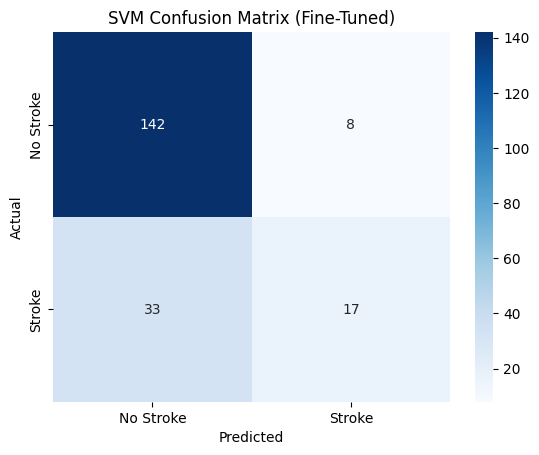

In [ ]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Stroke', 'Stroke'],
    yticklabels=['No Stroke', 'Stroke']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix (Fine-Tuned)')
plt.show()

- แม้ accuracy ลดลง แต่โมเดลถูกปรับให้เหมาะสมกับบริบททางการแพทย์
โดยให้ความสำคัญกับการลด False Negative
ซึ่งมี cost สูงกว่าการแจ้งเตือนเกินจริง